# Patent-Intensity — a quantitative teardown 🔬
### R&D-intensity ranking with a reporting lag · long-short & long-minus-SPY HAC *t* · a random-blind-split sector control · fraction robustness · costs + short-borrow · a synthetic planted-premium / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Innovation_premium%3F: Misattributed](https://img.shields.io/badge/Innovation_premium%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We split the 'innovation premium' into the two questions a label fuses: is the long-high / short-low R&D-intensity spread **statistically real** (HAC *t* ≥ 2 on the tape), and is it a *distinct innovation factor* or **sector/style beta** that costs and short-borrow erase? The decisive objects are the **HAC t** of the spread, the **random-split** control (is it the R&D signal or any split of a mixed field?), and a **fraction sweep** (does it survive concentration?).

> ⚠️ **Data + proxy note.** Issued-patent counts aren't on a free feed; we use **reported R&D / revenue** (SEC EDGAR `companyfacts`) as the audited proxy — input intensity, not output quality (the distinction Hirshleifer-Hsu-Li 2013 show is decisive). Returns: yfinance monthly total return, 2005→2026. Survivorship is named on the Signal axis (the basket is current-membership, but the bias is largely *common to both legs* of the long/short). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from patent_intensity import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    INTEN, RETS, SPY = data.load_real(allow_survivorship_bias=True)
    RACE = st.race(INTEN, RETS, SPY, frac=1/3, report_lag=1, cost_bps=10.0,
                   borrow_bps=100.0, n_draws=2000)
else:
    INTEN = RETS = SPY = RACE = None
print("real EDGAR+yfinance cache present:", HAVE_REAL,
      "| field names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-02', 'end': '2026-05', 'months': 256, 'years': 21.3, 'field': 40, 'intensity_names': 39, 'fingerprint': '66d4e99b7bf1', 'long_members': ['ADBE', 'AMGN', 'BMY', 'CSCO', 'GILD', 'IBM', 'INTC', 'LLY', 'MRK', 'ORCL', 'PFE', 'QCOM', 'TXN'], 'short_members': ['AXP', 'C', 'COST', 'DUK', 'HD', 'KO', 'LOW', 'MCD', 'MMM', 'T', 'USB', 'VZ', 'WMT'], 'long': (13.64, 0.94, -36.9, 13.95), 'short': (9.71, 0.72, -46.1, 10.35), 'long_short': (2.98, 0.31, -26.6, 3.6), 'spy': (11.11, 0.78, -50.8, 11.7), 'long_net_cagr': 13.61, 'test_ls': (3.6, 1.5, 256), 'test_long_spy': (2.25, 1.21, 256), 'test_short_spy': (-1.35, -0.76, 256), 'rand_mean': 0.08, 'rand_med': 0.05, 'rand_sd': 1.77, 'ls_pctile': 97.9, 'robust': [(0.5, 20, 4.12, 2.18), (0.3333333333333333, 13, 3.6, 1.5), (0.25, 10, 3.28, 1.29), (0.2, 8, 3.28, 1.13)], 'ls_gross': (3.6, 1.5), 'ls_net': (2.6, 1.08), 'syn': [(0.0, -1.34, -0.69), (0.06, 4.33, 2.23)]}


real EDGAR+yfinance cache present: True | field names: 40


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | long-short **+3.60%/yr**, HAC **t = 1.50** (n = 256); clears t = 2 *only* at the "halves" split (2.18), fails at tertile/quartile/quintile. |
| **Tradability** | `MIRAGE` | net of 10 bps turnover **+ 100 bps/yr short-borrow** the spread is **+2.60%/yr at t = 1.08** — zero, statistically. Long-only beats SPY by only +2.25%/yr (t = 1.21). |
| **Innovation premium?** | `MISATTRIBUTED` | the split sits at the **98th pct** of random splits — a *real* axis, but it is the growth/tech-vs-value style axis (long = semis/software/pharma, short = banks/staples/retail), not a patent-specific alpha. |

> 💡 In plain words: R&D intensity sorts stocks onto a genuine cross-sectional axis (not noise) — but that axis is *style*, the spread doesn't clear significance, and borrow finishes whatever is left.

## 1 · The claim, steelmanned

Let $x_{i,y}$ be firm $i$'s R&D intensity (R&D / revenue) reported for fiscal year $y$. Form, at the start of year $Y$, the long-high / short-low book from $x_{i,Y-1}$ (a one-year reporting lag — no look-ahead):

$$\text{LS}_Y = \frac1k\!\!\sum_{i\in \text{top-}k} r_{i,Y} \;-\; \frac1k\!\!\sum_{i\in \text{bot-}k} r_{i,Y}.$$

- **H₁ (the premium is real).** $\mathbb{E}[\text{LS}] > 0$ with a HAC $t \ge 2$ — a *significant* innovation spread.
- **H₂ (it's deployable).** The spread survives one-way costs **and the borrow you pay to be short**, and holds up when you *concentrate* (tighter tertiles).
- **H₃ (it's *innovation*).** The spread is distinct from the style/sector axis — it is not reproduced by 'long tech, short banks' generically.

We find **H₁ not supported** (+3.60%/yr but $t = 1.50$, and significant only at the barely-sorted halves), **H₂ rejected** (net of borrow $t = 1.08$; long-only is mostly growth beta), **H₃ rejected** (the spread *is* the style axis — 97.9th pct of random splits, but those names *are* growth-vs-value). The label is true where it's uninformative (tech has out-earned value) and unproven where it would pay (a *distinct, significant* invention alpha).

## 2 · So what? — what rides on each answer

The teardown is one decomposition: a long-short mean against zero, judged by its **HAC standard error**, and against the **sampling distribution of any split** of the field.

$$t_{\text{HAC}} = \frac{\overline{\text{LS}}}{\widehat{\text{se}}_{\text{NW}}(\overline{\text{LS}})}, \qquad \text{pctile} = \Pr_{\text{random split}}\!\big[\overline{\text{LS}}_{\text{rand}} < \overline{\text{LS}}_{\text{R\&D}}\big].$$

A high **percentile** says R&D loads on a real axis (not noise); a low **t** says that axis's *return* gap is inside its own error bar. Both can be true at once — and here they are. The honest read needs both numbers: the percentile kills 'it's just luck,' the *t* kills 'it's a certified edge,' and the names kill 'it's about *invention*.'

## 3 · How we'd know — the protocol

- **Intensity panel.** Annual `ResearchAndDevelopmentExpense` / revenue from SEC EDGAR `companyfacts` for a fixed 40-name field (39 with a series), 10-K full-year facts only; missing R&D floored to 0 (banks genuinely don't patent). **Proxy** for patent intensity — input, not output.
- **Books.** Each year, equal-weight top-tertile (long) / bottom-tertile (short) by intensity *known at formation* (fiscal-year $Y-1$, a 1-year reporting lag). Annual rebalance.
- **Null #1 (HAC t).** Newey-West t of the monthly long-short and long-minus-SPY means (`REAL` needs $t \ge 2$).
- **Null #2 (random split).** 2,000 blind $k$-long/$k$-short draws of the same names; where the R&D split sits is the sector/heterogeneity control.
- **Robustness.** Fraction sweep halves→quintiles; report-lag 1 vs 2.
- **Costs.** 10 bps one-way turnover **+ a 100 bps/yr borrow on the short leg** (a long/short pays to be short).
- **Positive control.** A deterministic panel with a *planted* annual premium `edge`: the harness must recover a large edge **and** must NOT manufacture significance at `edge = 0`.

## 4 · The teardown

### 4a · The point estimate — positive, small, and it fails the bar

The long-short and long-minus-SPY spreads with their HAC *t*. Positive, but neither clears 2; the short leg merely lags the market.

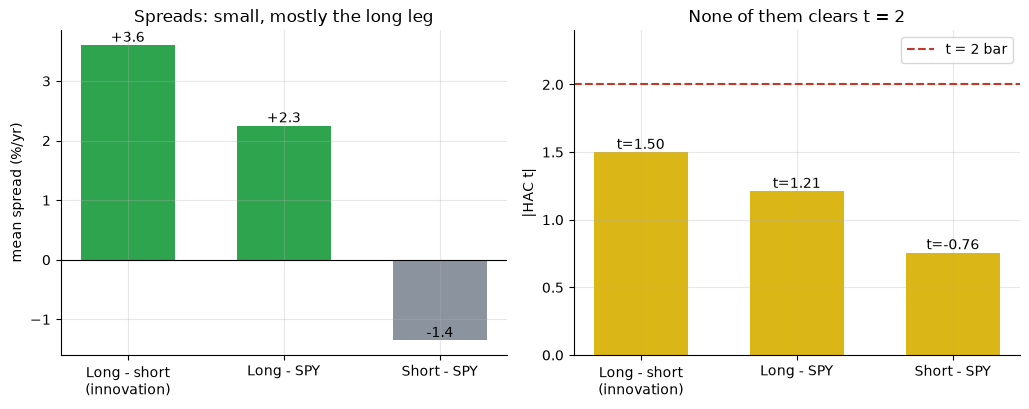

long-short +3.60%/yr t=1.50 | long-SPY +2.25%/yr t=1.21


In [2]:
if HAVE_REAL:
    rows = [('Long - short\n(innovation)', RACE['test_ls']),
            ('Long - SPY', RACE['test_long_vs_spy']),
            ('Short - SPY', RACE['test_short_vs_spy'])]
    labels = [r[0] for r in rows]; means = [r[1]['mean_ann']*100 for r in rows]
    ts = [r[1]['tstat'] for r in rows]
else:
    labels = ['Long - short\n(innovation)', 'Long - SPY', 'Short - SPY']
    means = [R['test_ls'][0], R['test_long_spy'][0], R['test_short_spy'][0]]
    ts = [R['test_ls'][1], R['test_long_spy'][1], R['test_short_spy'][1]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
cols = [GREEN if m > 0 else GREY for m in means]
a1.bar(labels, means, color=cols, width=.6); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('mean spread (%/yr)'); a1.set_title('Spreads: small, mostly the long leg')
for i, m in enumerate(means): a1.annotate(f'{m:+.1f}', (i, m), ha='center', va='bottom')
a2.bar(labels, [abs(t) for t in ts], color=AMBER, width=.6)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, t in enumerate(ts): a2.annotate(f't={t:.2f}', (i, abs(t)), ha='center', va='bottom')
a2.set_ylabel('|HAC t|'); a2.set_ylim(0, 2.4); a2.set_title('None of them clears t = 2'); a2.legend()
plt.tight_layout(); plt.show()
print('long-short', f"{R['test_ls'][0]:+.2f}%/yr t={R['test_ls'][1]:.2f}",
      '| long-SPY', f"{R['test_long_spy'][0]:+.2f}%/yr t={R['test_long_spy'][1]:.2f}")

> 💡 In plain words: the innovation spread is **+3.60%/yr** at **t = 1.50** — positive but *not* significant. And it's lopsided: long-minus-SPY is +2.25%/yr (t = 1.21) while short-minus-SPY is -1.35%/yr (t = -0.76) — the 'premium' is mostly the long leg's mild out-performance, not a clean two-sided edge.

### 4b · Is it the R&D signal, or any split of a mixed field?

Draw 2,000 *blind* long/shorts (same leg sizes, names random, **no R&D used**). Where the R&D split lands tells us whether intensity carries information — and the answer is a careful *yes, but*.

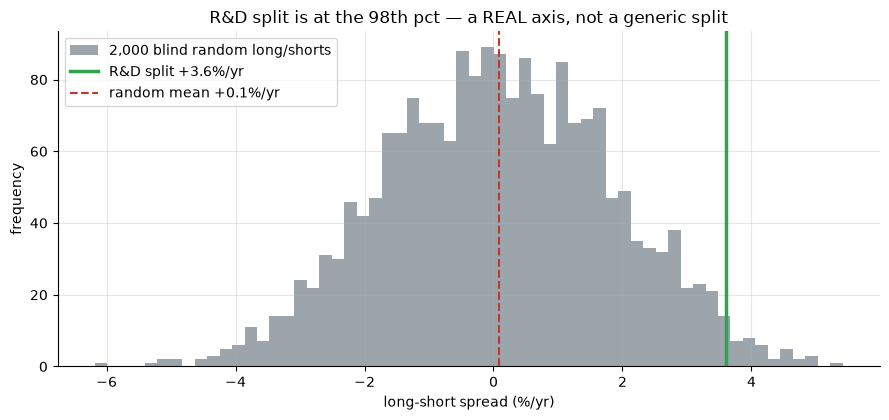

random split ~0%/yr (no info); R&D split +3.6%/yr at 98th pctile
=> R&D loads on a persistent axis -- but the names show that axis is growth-vs-value (style)


In [3]:
if HAVE_REAL:
    rand = RACE['rand_ls_spread']*100; obs = RACE['test_ls']['mean_ann']*100
    pct = RACE['ls_pctile']
else:
    rng = np.random.default_rng(400); rand = rng.normal(R['rand_mean'], R['rand_sd'], 2000)
    obs = R['test_ls'][0]; pct = R['ls_pctile']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand, bins=60, color=GREY, alpha=.85, label='2,000 blind random long/shorts')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'R&D split {obs:+.1f}%/yr')
ax.axvline(np.mean(rand), c=RED, ls='--', label=f'random mean {np.mean(rand):+.1f}%/yr')
ax.set_xlabel('long-short spread (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'R&D split is at the {pct:.0f}th pct — a REAL axis, not a generic split')
ax.legend(); plt.tight_layout(); plt.show()
print(f'random split ~0%/yr (no info); R&D split {obs:+.1f}%/yr at {pct:.0f}th pctile')
print('=> R&D loads on a persistent axis -- but the names show that axis is growth-vs-value (style)')

> 💡 In plain words: a *random* split pays ≈0%/yr, so the R&D split's +3.6%/yr (the **98th percentile**) is **not** a generic artefact — intensity really does load on a persistent cross-sectional axis. The catch is *which* axis: the long names are semis/software/pharma and the short names are banks/staples/retail. That is the **growth-vs-value** axis. The control rescues R&D from 'pure noise' and convicts it of 'style beta' in the same breath. Combined with 4a's $t = 1.50$: a real *style* tilt, an unproven *return*.

### 4c · Robustness — fragile to specification

Tighten the sort from halves to quintiles. The spread clears $t = 2$ **only** at the coarsest split (where each 'leg' is half the field — barely a tilt); every concentrated, tradable split fails.

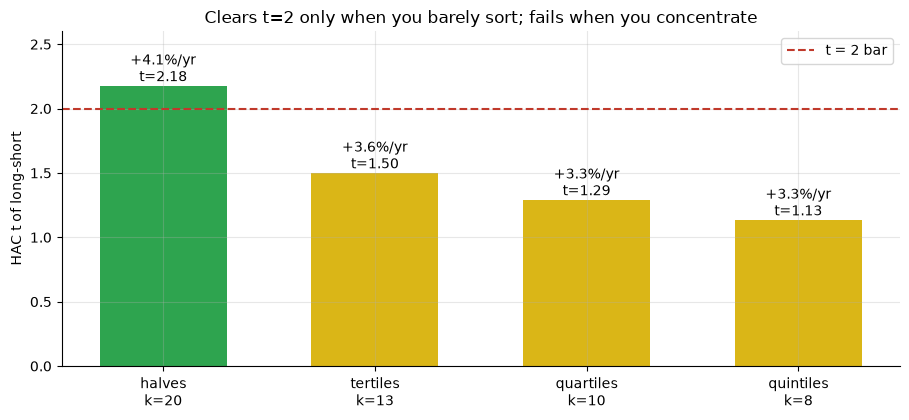

robustness (frac, k, mean%/yr, t): [(0.5, 20, 4.12, 2.18), (0.33, 13, 3.6, 1.5), (0.25, 10, 3.28, 1.29), (0.2, 8, 3.28, 1.13)]


In [4]:
if HAVE_REAL:
    rob = []
    for frac in (0.50, 1/3, 0.25, 0.20):
        b = st.intensity_books(INTEN, RETS, frac=frac)
        t = st.hac_tstat(b['long_short']); k = len(b['members'][max(b['members'])][0])
        rob.append((frac, k, t['mean_ann']*100, t['tstat']))
else:
    rob = R['robust']
labels = ['halves', 'tertiles', 'quartiles', 'quintiles']
ks = [r[1] for r in rob]; tt = [r[3] for r in rob]; ms = [r[2] for r in rob]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
bars = ax.bar([f'{l}\nk={k}' for l, k in zip(labels, ks)], tt,
              color=[GREEN if t >= 2 else AMBER for t in tt], width=.6)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for b, m, t in zip(bars, ms, tt):
    ax.annotate(f'{m:+.1f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, t), ha='center', va='bottom')
ax.set_ylabel('HAC t of long-short'); ax.set_ylim(0, 2.6)
ax.set_title('Clears t=2 only when you barely sort; fails when you concentrate'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (frac, k, mean%/yr, t):', [(round(r[0],2), r[1], round(r[2],2), round(r[3],2)) for r in rob])

> 💡 In plain words: at the **halves** split (k = 20/leg — basically 'top half vs bottom half') the t is 2.18, just over the bar. Sort into **tertiles** and it's 1.50; **quintiles**, 1.13. A genuine factor gets *stronger* as you concentrate on its extremes; this gets *weaker*. That inversion is the signature of a `WEAK`, specification-fragile effect (and the report-lag isn't the culprit — lag 2 gives t = 1.53).

### 4d · Costs + short-borrow — the little that's there, leaks

Turnover is trivial (annual rebalance), but a long/short pays **borrow** on its short leg. A modest 100 bps/yr borrow drops the already-insignificant gross spread further.

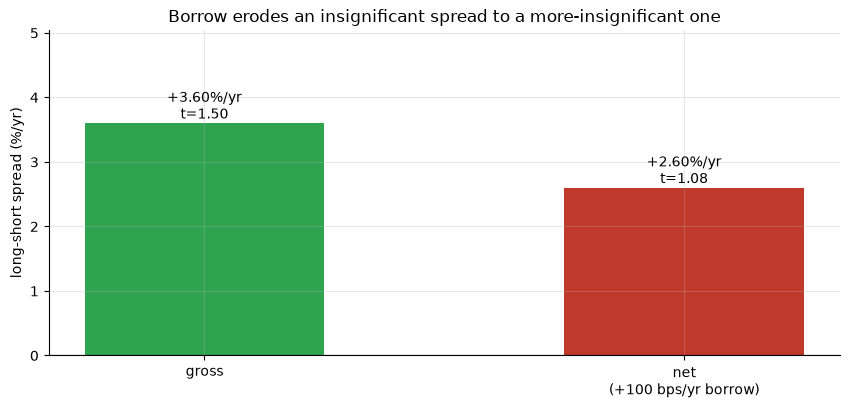

gross +3.60%/yr (t=1.50) -> net +2.60%/yr (t=1.08)


In [5]:
g, gt = R['ls_gross']; n, nt = R['ls_net']
fig, ax = plt.subplots(figsize=(8.6, 4.2))
bars = ax.bar(['gross', 'net\n(+100 bps/yr borrow)'], [g, n], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short spread (%/yr)'); ax.set_ylim(0, g*1.4)
for b, v, t in zip(bars, [g, n], [gt, nt]):
    ax.annotate(f'{v:+.2f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.set_title('Borrow erodes an insignificant spread to a more-insignificant one')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}%/yr (t={gt:.2f}) -> net {n:+.2f}%/yr (t={nt:.2f})')

> 💡 In plain words: gross **+3.60%/yr (t = 1.50)** → net **+2.60%/yr (t = 1.08)**. The borrow isn't the only problem — the gross was never significant — but it confirms there is no costed, shortable edge to allocate to. The deployable object is the long-only growth tilt, which a style ETF gives you cheaper.

### 4e · Faithful-engine & power control — we know the truth here

A deterministic panel (40 names, 18 years) where the first half are persistently high-intensity, the market beta is common to both legs, and `edge` plants the *true* annual long-high-minus-short-low premium. With `edge = 0` the long-short must stay insignificant; a large planted edge must light up.

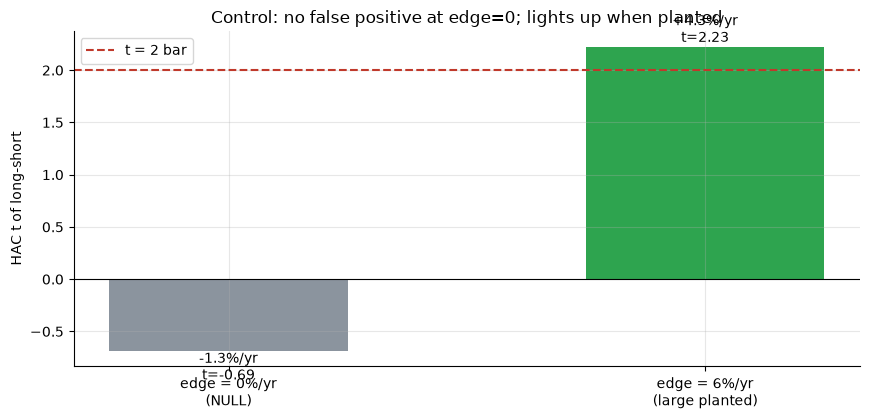

edge=0.00: long-short -1.34%/yr  HAC t=-0.69
edge=0.06: long-short +4.33%/yr  HAC t=2.23


In [6]:
res = []
for edge in (0.0, 0.06):
    i2, r2, b2, truth = data.synthetic_panel(edge=edge)
    bk = st.intensity_books(i2, r2); t = st.hac_tstat(bk['long_short'])
    res.append((edge, t['mean_ann']*100, t['tstat']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'edge = {e*100:.0f}%/yr\n({"NULL" if e==0 else "large planted"})' for e,_,_ in res]
tvals = [r[2] for r in res]
bars = ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(0, c='k', lw=.8)
for b, (e, m, t) in zip(bars, res):
    ax.annotate(f'{m:+.1f}%/yr\nt={t:.2f}', (b.get_x()+b.get_width()/2, t),
                ha='center', va='bottom' if t >= 0 else 'top')
ax.set_ylabel('HAC t of long-short'); ax.set_title('Control: no false positive at edge=0; lights up when planted')
ax.legend(); plt.tight_layout(); plt.show()
for e, m, t in res: print(f'edge={e:.2f}: long-short {m:+.2f}%/yr  HAC t={t:.2f}')

> 💡 In plain words: with **no** planted premium the control sits at **t = -0.69** (no false positive — the harness doesn't conjure an edge); only a **large** +6%/yr planted premium reaches **t = 2.23**. So the machinery is honest, and the real-tape **t = 1.50** reads as exactly what an *absent-or-tiny* edge looks like through a 21-year keyhole — not a bug, just a weak tape.

## 5 · The verdict

- **Signal `WEAK`** — long-short **+3.60%/yr** at HAC **t = 1.50** (n = 256); significant *only* at the barely-sorted halves (2.18), fragile to concentration. Published support + a positive-but-insignificant, specification-fragile estimate ⇒ `WEAK`, not `REAL`.
- **Tradability `MIRAGE`** — net of 10 bps turnover **+ 100 bps/yr short-borrow** the spread is **+2.60%/yr (t = 1.08)** — zero, statistically. The only deployable object is a long-only growth tilt (+2.25%/yr vs SPY, t = 1.21) you can buy more cheaply as a style ETF.
- **Innovation premium? `MISATTRIBUTED`** — the split is a *real* axis (**98th pct** of random splits) but it is the growth/tech-vs-value style axis (long = semis/software/pharma, short = banks/staples/retail), not a patent-specific alpha. The premium is attributed to *invention*; it is *style beta*.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* long-short premium have to be for a $T$-month study to detect it at $t = 2$, given the spread's realised volatility? Our 256-month tape can only certify edges far above the ~3.6%/yr we see.

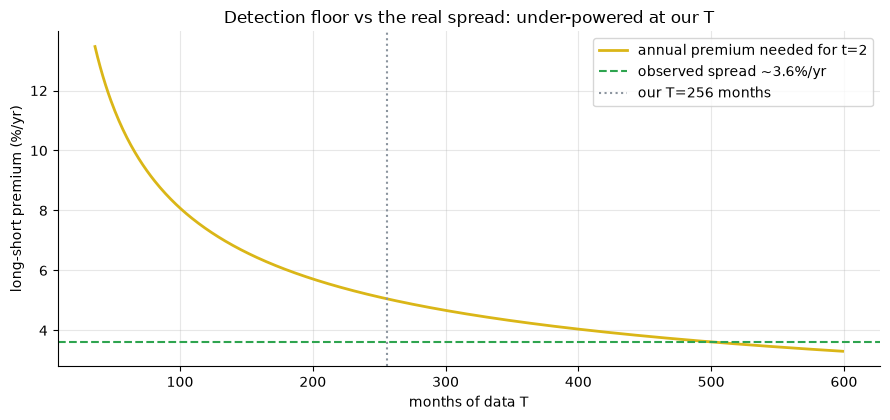

at T=256 you need ~5.1%/yr for t=2; observed ~3.6%/yr -> under-powered by ~1.4x


In [7]:
if HAVE_REAL:
    ls = RACE['long_short'].dropna(); sd_m = ls.std(ddof=1)
    obs_ann = RACE['test_ls']['mean_ann']*100
else:
    sd_m = 0.045; obs_ann = R['test_ls'][0]
Ts = np.arange(36, 600)
# min annual mean detectable at t=2 (iid approx): 2*sd_month*12/sqrt(T)
min_det = 2.0 * sd_m * 12.0 / np.sqrt(Ts)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(Ts, min_det*100, c=AMBER, lw=2, label='annual premium needed for t=2')
ax.axhline(obs_ann, c=GREEN, ls='--', label=f'observed spread ~{obs_ann:.1f}%/yr')
ax.axvline(R['months'], c=GREY, ls=':', label=f"our T={R['months']} months")
ax.set_xlabel('months of data T'); ax.set_ylabel('long-short premium (%/yr)')
ax.set_title('Detection floor vs the real spread: under-powered at our T'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd_m*12.0/np.sqrt(R['months'])*100
print(f'at T={R["months"]} you need ~{need:.1f}%/yr for t=2; observed ~{obs_ann:.1f}%/yr '
      f'-> under-powered by ~{need/obs_ann:.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable premium** at our sample length; the green line is what we actually see. The observed spread sits *below* the detection floor for 21 years of data — to certify a +3.6%/yr long-short at t = 2 you'd need several times the history (or a much cleaner, lower-vol spread). Even granting the literature a *real* small premium, this tape cannot prove it — and the random-split control says what little is there is **style**, not invention. There is no sort, no horizon, and no cost assumption on this field that turns audited R&D intensity into a distinct, significant, tradable innovation edge.

## 7 · Going further

- **Input vs output.** Hirshleifer-Hsu-Li (2013): the surviving premium is **innovative *efficiency*** (patents/citations per R&D dollar), not gross intensity. Our proxy is input-only — plug in real patent-value data (Kogan-Papanikolaou-Seru-Stoffman) and re-test H₃.
- **Style-strip.** Regress the long-short on an explicit growth-vs-value factor (or HML); the random-split control predicts little residual alpha survives — confirm it.
- **Wider field.** 40 names is a transparent slice; run the same ranking on the full S&P 500 with sector-neutralisation. The power improves, but the *attribution* question (innovation vs style) is the one that decides the verdict.

*The reproducible core is offline and deterministic; intensity is an explicit proxy (R&D / revenue), not issued patents. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*